In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Bubble_plot/Bubble_plot.xlsx"
df = pd.read_excel(dataset_total_path)

df = df.groupby(['Class', ' '], as_index = False).mean('Abundance')
df.head()

,Class,,Abundance,
0,Alkaloids,Secondary,24.069054,24.0
1,Amino acids,Primary,25.092940,12.0
2,Benzenoids,Secondary,24.650934,17.0
3,Carbohydrates,Primary,25.239664,24.0
4,Cinnamic acids and derivatives,Secondary,25.652977,19.0


In [3]:
mean_abundance = df['Abundance'].mean()
mean_abundance

np.float64(24.363574493735715)

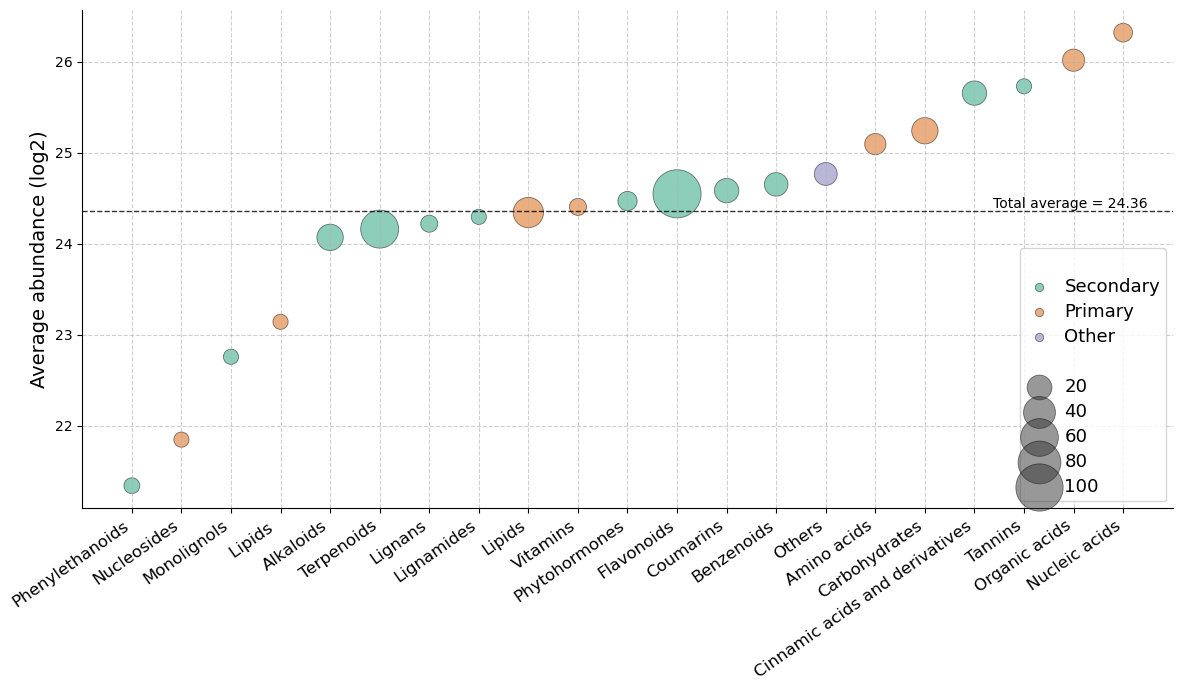

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# df_sum: columns = ["Class", "Abundance", "Counts"]
df = df.copy()

# Optional: order classes by abundance (or Counts) so the x-axis is meaningful
df["Class"] = pd.Categorical(
    df["Class"],
    categories=df.sort_values("Abundance")["Class"],
    ordered=True
)

plt.figure(figsize=(12, 7))
ax = sns.scatterplot(
    data=df,
    x="Class",
    y="Abundance",
    size="  ",
    sizes=(120, 1200),       # adjust bubble area range
    alpha=0.5,
    hue = df[' '],
    palette = 'Dark2',
    edgecolor="black",
    linewidth=0.6,
    legend="brief"
)

ax.axhline(
    y=mean_abundance,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.8
)

ax.text(
    len(df) - 0.5,      # right side of the plot
    mean_abundance,
    f"Total average = {mean_abundance:.2f}",
    ha="right",
    va="bottom",
    fontsize=10,
    color="black"
)

plt.grid(True, which='both', linestyle='--', alpha=0.6)

leg = ax.legend_
leg.set_title("")
for text in leg.texts:
    text.set_fontsize(13)   

# Cosmetics
ax.set_xlabel("")
ax.set_ylabel("Average abundance (log2)", fontsize=14)
ax.tick_params(axis="x", labelsize=12)
plt.xticks(rotation=35, ha="right")

sns.despine()
plt.tight_layout()



plt.savefig("C:/Users/tamer/Documents/PhD/ML/Bubble_plot/Bubble_plot.pdf", format="pdf", bbox_inches="tight")   
plt.savefig("C:/Users/tamer/Documents/PhD/ML/Bubble_plot/Bubble_plot.png", dpi=600, bbox_inches="tight")  


plt.show()